c:\Users\alexb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


R²: 0.46237503631218313
MAE: 50.16300244558361
RMSE: 72.01171347994831


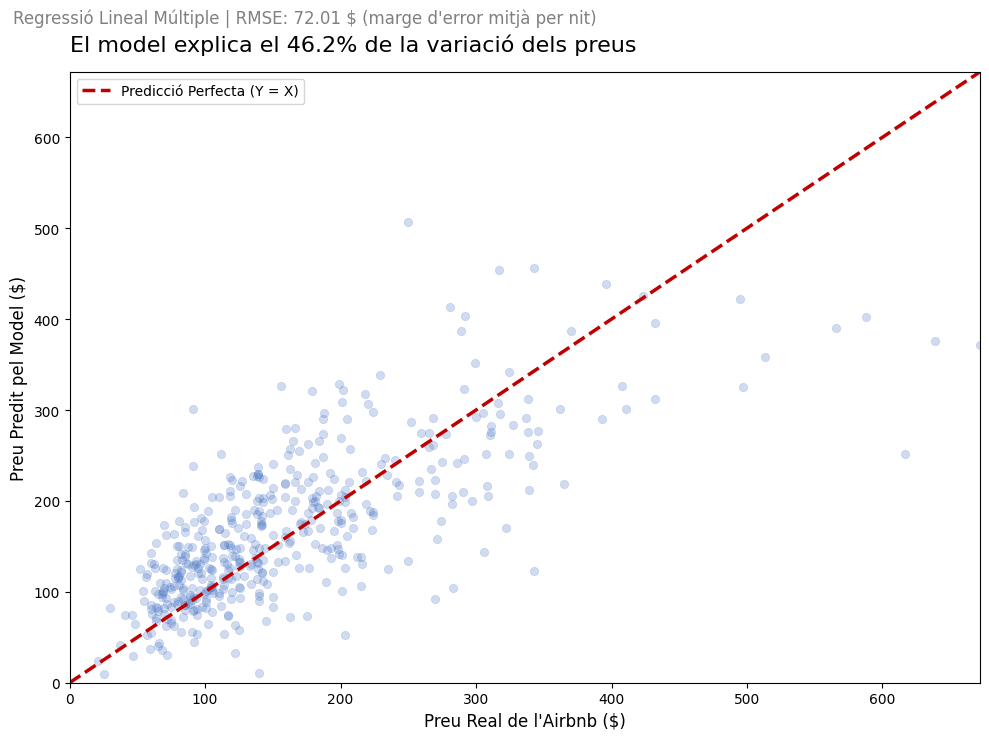


Les 4 variables més significatives segons el test F-regression són:
['num__bathrooms', 'num__accommodates', 'num__bedrooms', 'num__beds']


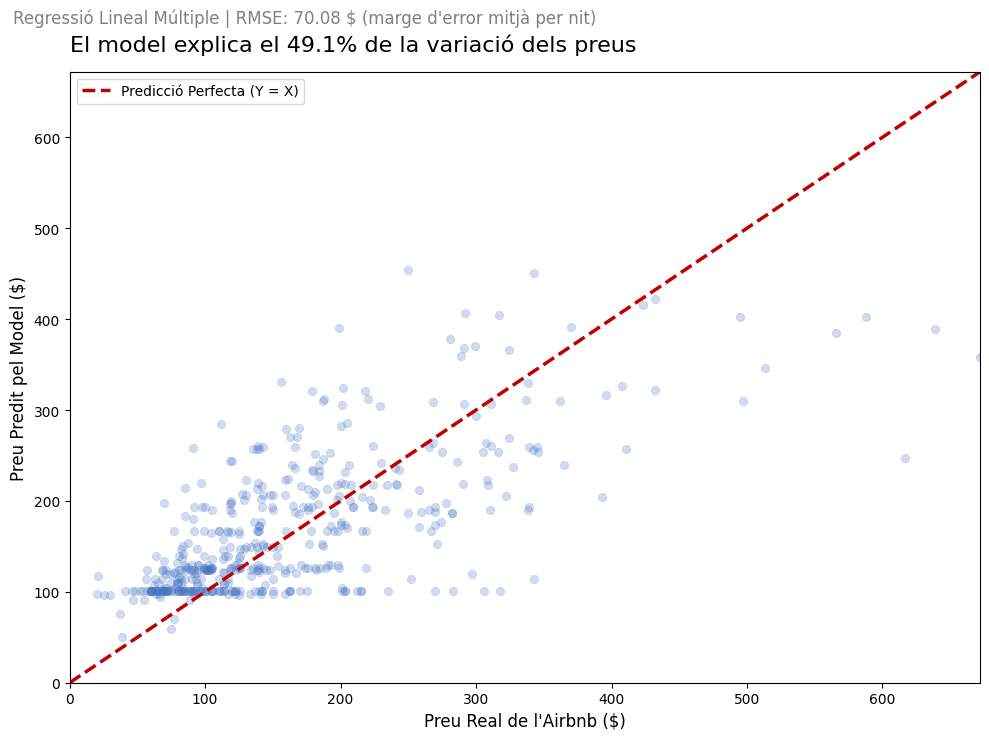

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm # Per a mapes de colors avançats

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

CARPETA_SORTIDA = "outputs/grafics"

df = pd.read_csv("dataset/listings.csv.gz", compression="gzip")

df["price_clean"] = (
    df["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

features = [
    "neighbourhood_cleansed",
    "room_type",
    "property_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "reviews_per_month",
    "review_scores_rating",
    "estimated_occupancy_l365d",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes"
]

target = "price_clean"

df_model = df[features + [target]].copy()

# Eliminem files sense preu
df_model = df_model.dropna()

# Eliminem preus extrems per no distorsionar el model
limit_preu = df_model[target].quantile(0.99)
df_model = df_model[df_model[target] <= limit_preu]

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identifiquem les columnes categòriques i numèriques
categorical_cols = ["neighbourhood_cleansed", "room_type", "property_type"]
numerical_cols = [col for col in features if col not in categorical_cols]

# Preprocessing: One-Hot Encoding per a variables categòriques i mantenir les numèriques sense canvis
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

model = LinearRegression()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

plt.figure(figsize=(10, 8))

# Dibuixem el gràfic de dispersió (Observacions Reals vs Prediccions)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.25, color="#4472C4", edgecolor=None)

# Dibuixem la recta de predicció perfecta (on el valor real és igual al predit)
max_val = y_test.max()
lims = [0, max_val]
plt.plot(lims, lims, color="#C00000", linestyle="--", linewidth=2.5, label="Predicció Perfecta (Y = X)")

# Títols orientats a conclusions
plt.title(f"El model explica el {r2*100:.1f}% de la variació dels preus", fontsize=16, loc="left", pad=15)

# Títol secundari corregit: l'RMSE ja està en dòlars reals
plt.suptitle(f"Regressió Lineal Múltiple | RMSE: {rmse:.2f} $ (marge d'error mitjà per nit)", 
             fontsize=12, color="gray", x=0.31, y=0.92)

plt.xlabel("Preu Real de l'Airbnb ($)", fontsize=12)
plt.ylabel("Preu Predit pel Model ($)", fontsize=12)
plt.xlim(lims)
plt.ylim(lims)
plt.legend(loc="upper left")
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    f"{CARPETA_SORTIDA}/regressio_lineal_asheville.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Fem proves seleccionant les variables més significatives segons el test F-regression
f_values, p_values = f_regression(X_train_encoded, y_train)

features_netes = preprocessor.get_feature_names_out()

importancia_df = pd.DataFrame({
    "Feature": features_netes,
    "F_value": f_values,
    "p_value": p_values
}).sort_values(by="F_value", ascending=False)

N_FEATURES = 4
top_indices = importancia_df.head(N_FEATURES).index.tolist()
top_features_names = importancia_df.head(N_FEATURES)["Feature"].tolist()

print(f"\nLes {N_FEATURES} variables més significatives segons el test F-regression són:")
print(top_features_names)

X_train_top = X_train_encoded[:, top_indices]
X_test_top = X_test_encoded[:, top_indices]

model_top = LinearRegression()
model_top.fit(X_train_top, y_train)

y_pred_top = model_top.predict(X_test_top)

r2_top = r2_score(y_test, y_pred_top)
rmse_top = np.sqrt(mean_squared_error(y_test, y_pred_top))

plt.figure(figsize=(10, 8))

# Dibuixem el gràfic de dispersió (Observacions Reals vs Prediccions)
sns.scatterplot(x=y_test, y=y_pred_top, alpha=0.25, color="#4472C4", edgecolor=None)

# Dibuixem la recta de predicció perfecta (on el valor real és igual al predit)
max_val = y_test.max()
lims = [0, max_val]
plt.plot(lims, lims, color="#C00000", linestyle="--", linewidth=2.5, label="Predicció Perfecta (Y = X)")

# Títols orientats a conclusions
plt.title(f"El model explica el {r2_top*100:.1f}% de la variació dels preus", fontsize=16, loc="left", pad=15)

# Títol secundari corregit: l'RMSE ja està en dòlars reals
plt.suptitle(f"Regressió Lineal Múltiple | RMSE: {rmse_top:.2f} $ (marge d'error mitjà per nit)", 
             fontsize=12, color="gray", x=0.31, y=0.92)

plt.xlabel("Preu Real de l'Airbnb ($)", fontsize=12)
plt.ylabel("Preu Predit pel Model ($)", fontsize=12)
plt.xlim(lims)
plt.ylim(lims)
plt.legend(loc="upper left")
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    f"{CARPETA_SORTIDA}/regressio_lineal_top_features_asheville.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [4]:
# ============================================================
# REGRESSIÓ SUPERVISADA - PREDICCIÓ DEL PREU AIRBNB ASHEVILLE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# 1. CARREGAR DATASET
# ============================================================

df = pd.read_csv("dataset/listings.csv.gz", compression="gzip")

# ============================================================
# 2. NETEJAR PRICE
# ============================================================

df["price_clean"] = (
    df["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

# ============================================================
# 3. SELECCIONAR VARIABLES
# ============================================================

features = [
    "neighbourhood_cleansed",
    "room_type",
    "property_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "reviews_per_month",
    "review_scores_rating",
    "estimated_occupancy_l365d",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes"
]

target = "price_clean"

df_model = df[features + [target]].copy()

# Eliminem files sense preu
df_model = df_model.dropna(subset=[target])

# Eliminem preus extrems per no distorsionar el model
limit_preu = df_model[target].quantile(0.99)
df_model = df_model[df_model[target] <= limit_preu]

print("Files utilitzades pel model:", len(df_model))

# ============================================================
# 4. SEPARAR X I y
# ============================================================

X = df_model[features]
y = df_model[target]

# X = dades d'entrada
# y = preu real que volem predir

# ============================================================
# 5. SEPARAR VARIABLES CATEGÒRIQUES I NUMÈRIQUES
# ============================================================

cat_features = [
    "neighbourhood_cleansed",
    "room_type",
    "property_type"
]

num_features = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "reviews_per_month",
    "review_scores_rating",
    "estimated_occupancy_l365d",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes"
]

# ============================================================
# 6. PREPROCESSAMENT
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_features
        ),
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_features
        )
    ]
)

# ============================================================
# 7. CREAR MODEL
# ============================================================

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42
    ))
])

# ============================================================
# 8. TRAIN / TEST
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Dades entrenament:", len(X_train))
print("Dades test:", len(X_test))

# ============================================================
# 9. ENTRENAR MODEL
# ============================================================

model.fit(X_train, y_train)

# ============================================================
# 10. FER PREDICCIONS
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# 11. AVALUAR RESULTATS
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nRESULTATS DEL MODEL")
print("------------------")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 3))

Files utilitzades pel model: 2511
Dades entrenament: 2008
Dades test: 503

RESULTATS DEL MODEL
------------------
MAE: 47.19
RMSE: 71.63
R2: 0.618


Distribució de les categories de preu:
price_category
50-150     1314
150-300     708
300+        249
0-50         73
Name: count, dtype: int64
Report de classificació:
              precision    recall  f1-score   support

        0-50       0.34      0.79      0.48        14
     150-300       0.52      0.48      0.50       142
        300+       0.42      0.58      0.49        50
      50-150       0.81      0.73      0.77       263

    accuracy                           0.64       469
   macro avg       0.52      0.64      0.56       469
weighted avg       0.67      0.64      0.65       469



c:\Users\alexb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


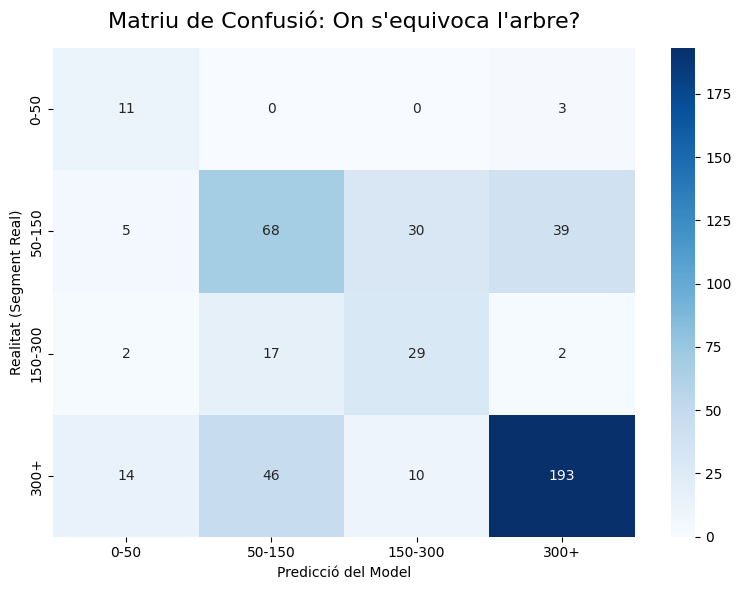

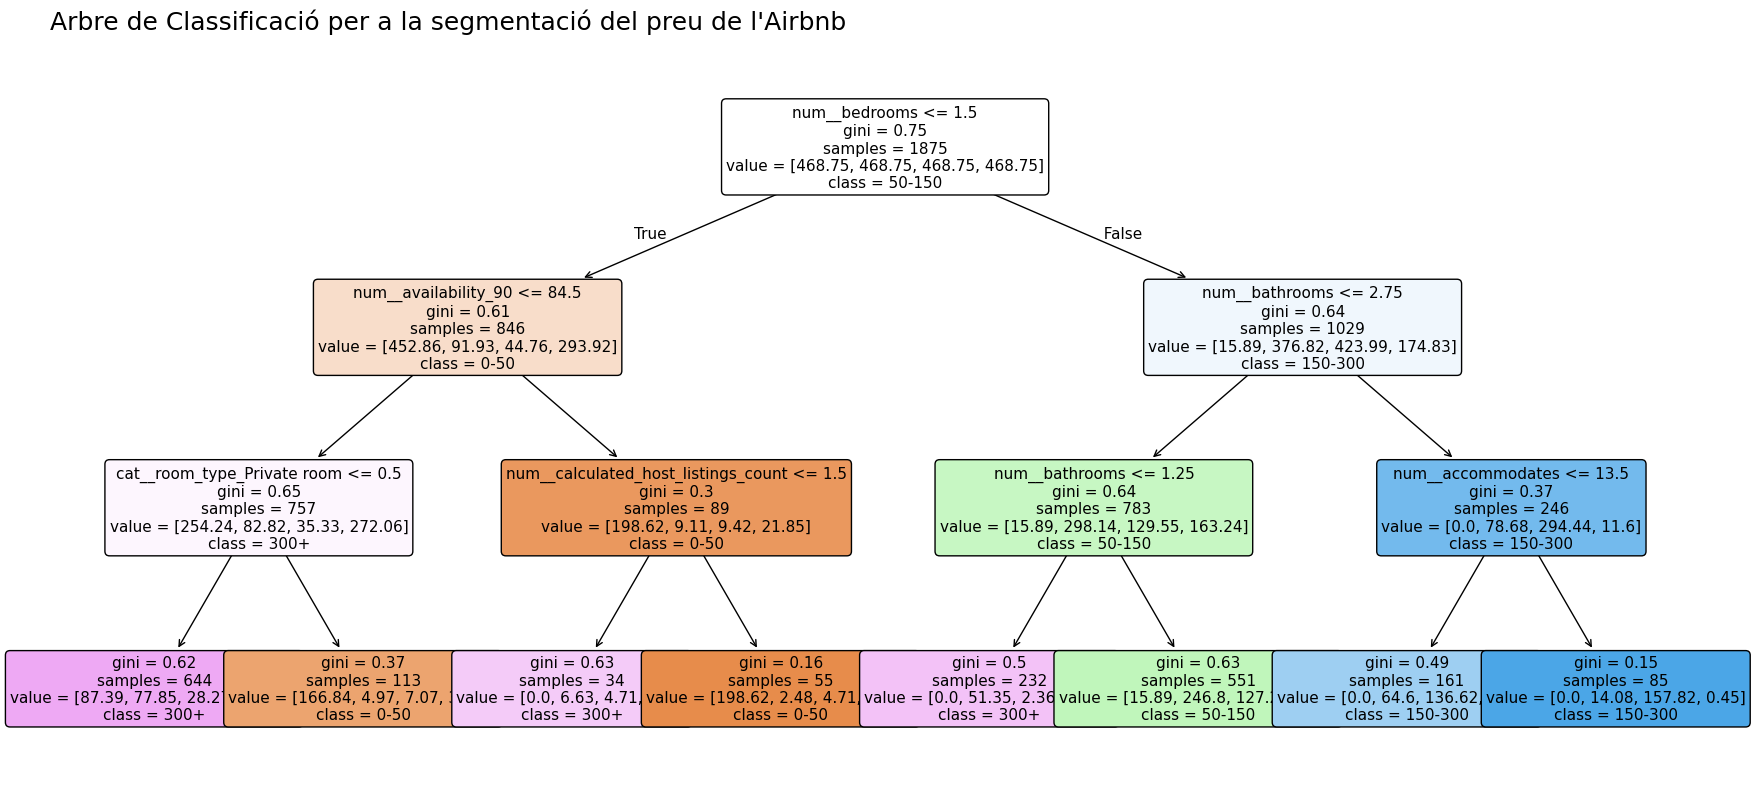

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm # Per a mapes de colors avançats

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

CARPETA_SORTIDA = "outputs/grafics"

df = pd.read_csv("dataset/listings.csv.gz", compression="gzip")



df["price_clean"] = (
    df["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

features = [
    "neighbourhood_cleansed",
    "room_type",
    "property_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "reviews_per_month",
    "review_scores_rating",
    "estimated_occupancy_l365d",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes"
]

target = "price_clean"

df_model = df[features + [target]].copy()

df = df_model.dropna()

bins = [0, 50, 150, 300, np.inf]
labels = ['0-50', '50-150', '150-300', '300+']

df['price_category'] = pd.cut(df['price_clean'], bins=bins, labels=labels)

print("Distribució de les categories de preu:")
print(df['price_category'].value_counts())

X = df.drop(columns=['price_clean', 'price_category'])
y = df['price_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identifiquem les columnes categòriques i numèriques
categorical_cols = ["neighbourhood_cleansed", "room_type", "property_type"]
numerical_cols = [col for col in features if col not in categorical_cols]

# Preprocessing: One-Hot Encoding per a variables categòriques i mantenir les numèriques sense canvis
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

model_arbre_cat = DecisionTreeClassifier(random_state=42, max_depth=3, class_weight='balanced')
model_arbre_cat.fit(X_train_encoded, y_train)

y_pred_cat = model_arbre_cat.predict(X_test_encoded)

print("Report de classificació:")
print(classification_report(y_test, y_pred_cat))

cm = confusion_matrix(y_test, y_pred_cat)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Matriu de Confusió: On s'equivoca l'arbre?", fontsize=16, pad=15)
plt.xlabel("Predicció del Model")
plt.ylabel("Realitat (Segment Real)")
plt.tight_layout()

plt.savefig(f"{CARPETA_SORTIDA}/matriu_confusio.png", dpi=300, bbox_inches="tight")

plt.show()

# DIBUIX DE L'ARBRE DE CLASSIFICACIÓ
plt.figure(figsize=(18, 8))
plot_tree(
    model_arbre_cat,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=labels,
    filled=True,
    rounded=True,
    fontsize=11,
    precision=2
)

plt.title("Arbre de Classificació per a la segmentació del preu de l'Airbnb", fontsize=18, loc="left", pad=20)
plt.tight_layout()

plt.savefig(f"{CARPETA_SORTIDA}/arbre_classificacio.png", dpi=300, bbox_inches="tight")

plt.show()


Files inicials: 2852
Columnes inicials: 79

Files després d'eliminar nuls bàsics: 2344

Files totals després de la neteja: 2320
Preu mínim: 18.0
Preu màxim: 886.0
Preu mitjà: 164.41
Mediana del preu: 130.0


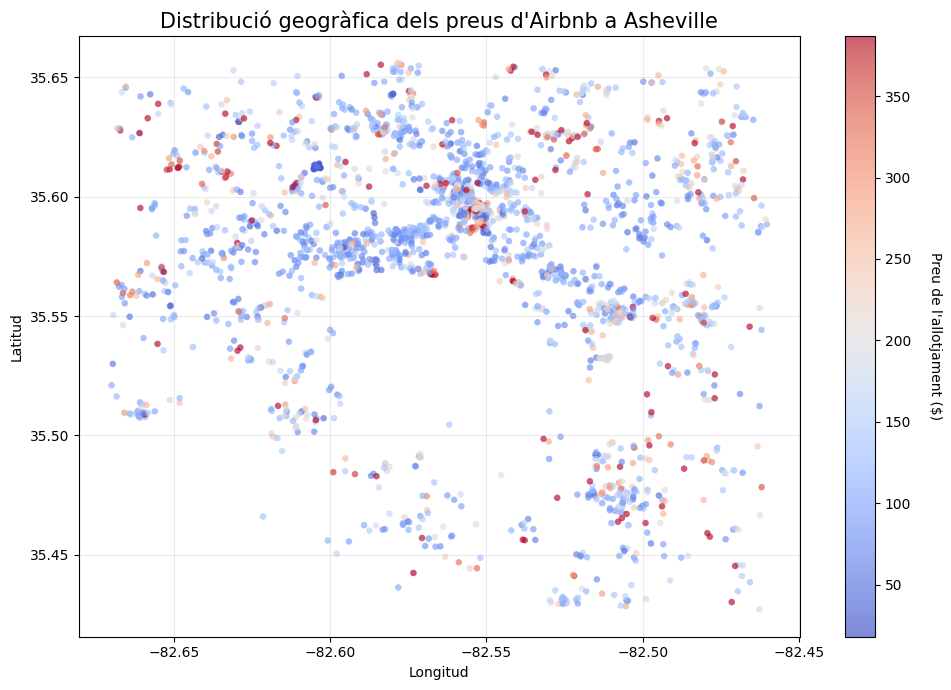

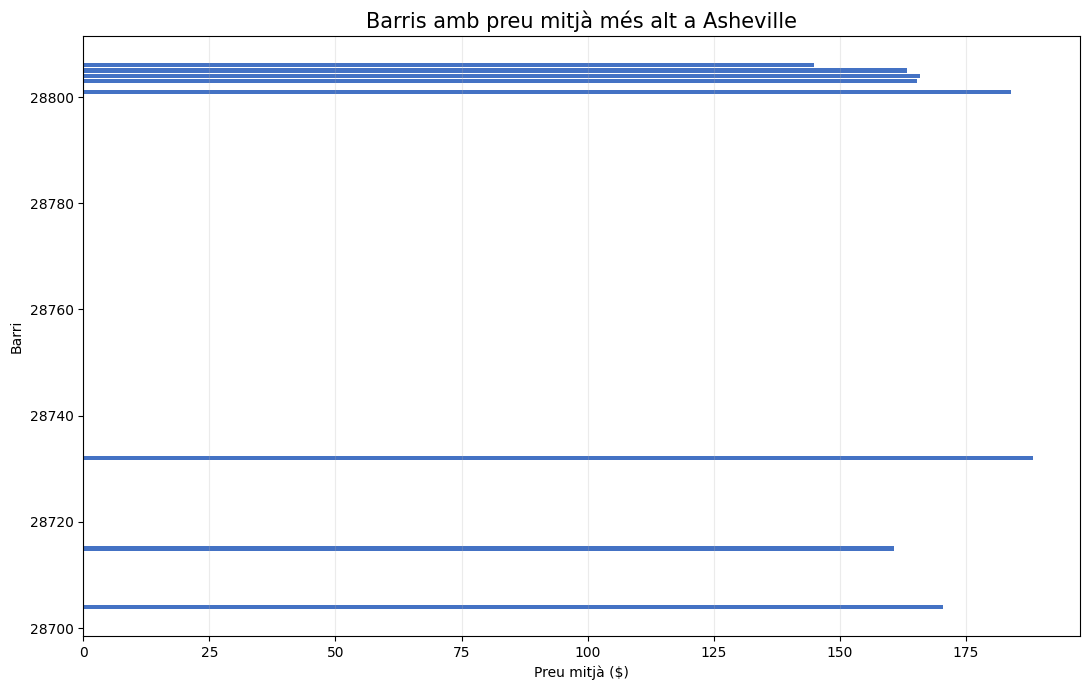

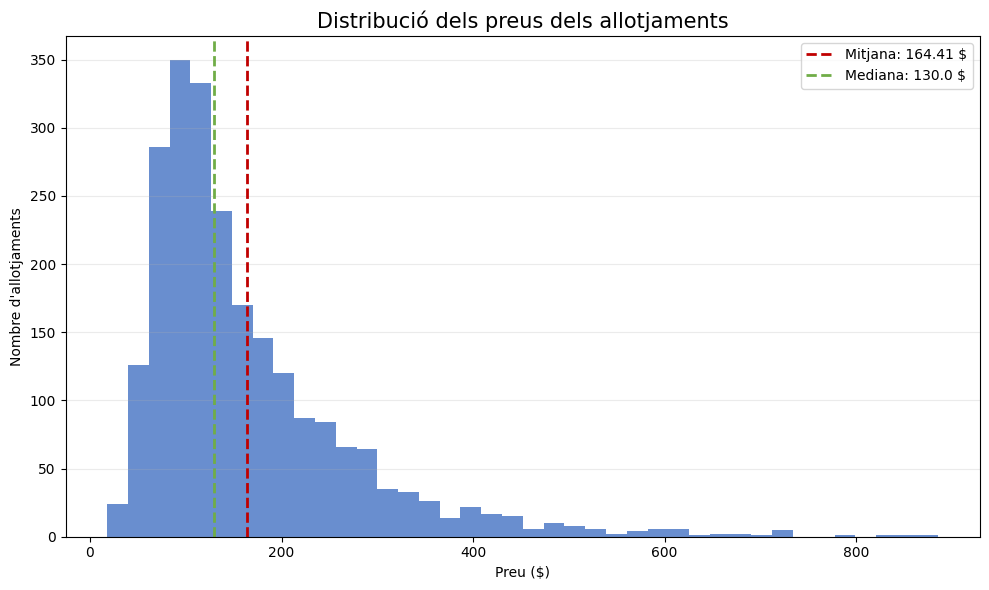

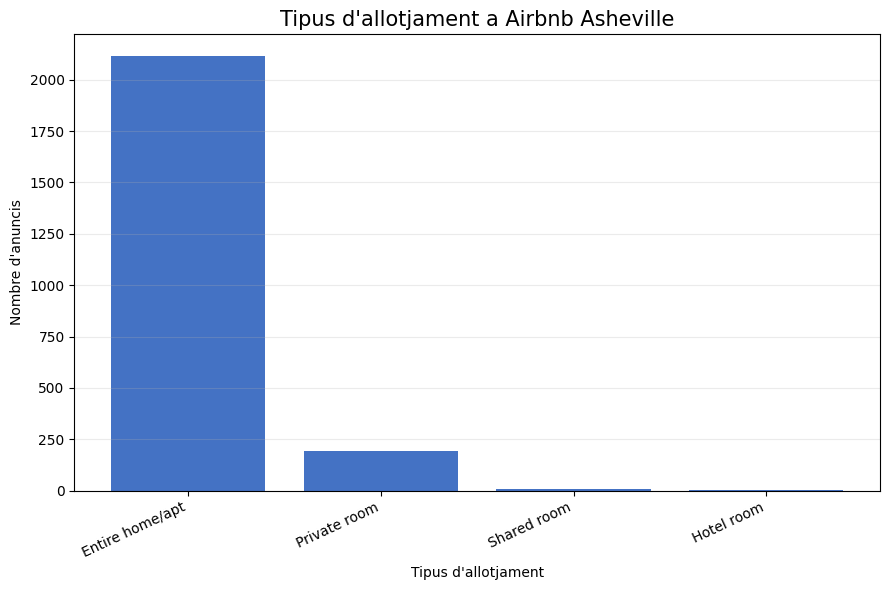


Generant Bar Chart de correlacions amb la Target...

RESUM FINAL
----------
Anuncis inicials: 2852
Anuncis amb preu i coordenades vàlides: 2344
Anuncis utilitzats als gràfics: 2320
Preu mínim: 18.0
Preu màxim visualitzat: 886.0
Preu mitjà: 164.41
Mediana: 130.0

Gràfics guardats a:
outputs/grafics


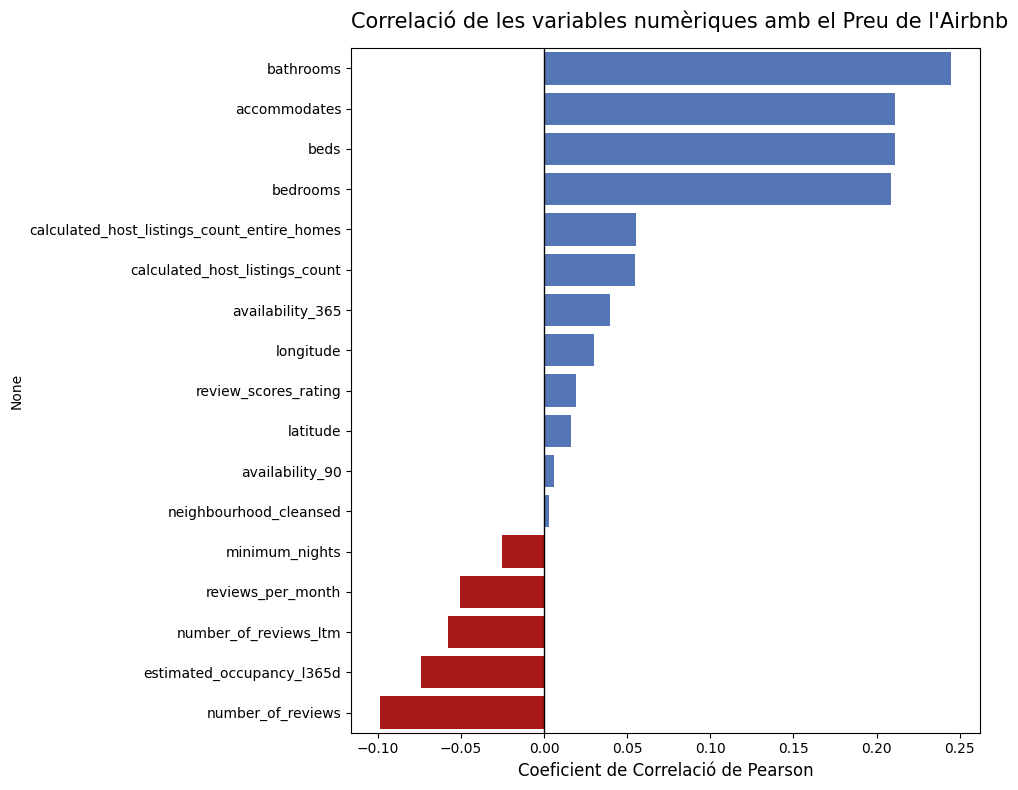

In [6]:
# ============================================================
# PRÀCTICA 3 - AIRBNB ASHEVILLE
# EXPLORACIÓ INICIAL I GRÀFICS PER AL STORYTELLING
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns

# ============================================================
# 1. CONFIGURACIÓ GENERAL
# ============================================================

RUTA_DATASET = "dataset/listings.csv.gz"
CARPETA_SORTIDA = "outputs/grafics"

os.makedirs(CARPETA_SORTIDA, exist_ok=True)

# Colors principals
MAIN_BLUE = "#4472C4"
ALERT_RED = "#C00000"
CLEAN_GREEN = "#70AD47"

# ============================================================
# 2. CARREGAR DATASET
# ============================================================

data = pd.read_csv(RUTA_DATASET, compression="gzip")
df = data.copy()

print("Files inicials:", len(df))
print("Columnes inicials:", len(df.columns))

# ============================================================
# 3. NETEJA DE LA VARIABLE PRICE
# ============================================================

# Airbnb acostuma a guardar el preu com a text: "$120.00"
df["price_clean"] = (
    df["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

# ============================================================
# 4. SELECCIÓ DE COLUMNES ÚTILS
# ============================================================

columnes_utiles = [
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "room_type",
    "property_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "reviews_per_month",
    "review_scores_rating",
    "estimated_occupancy_l365d",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "price_clean"
]

target = "price_clean"

features = [col for col in columnes_utiles if col != target]

df = df[columnes_utiles].copy()

# ============================================================
# 5. ELIMINACIÓ DE NULS BÀSICS
# ============================================================

df = df.dropna()

print("\nFiles després d'eliminar nuls bàsics:", len(df))

# ============================================================
# 6. ELIMINAR PREUS EXTREMS PER FER GRÀFICS MÉS LLEGIBLES
# ============================================================

# Per visualització, eliminem el 1% més car.
# Això evita que uns pocs allotjaments molt cars deformin l'escala de color.
limit_preu_99 = df["price_clean"].quantile(0.99)

df_plot = df[df["price_clean"] <= limit_preu_99].copy()

print("\nFiles totals després de la neteja:", len(df_plot))
print("Preu mínim:", df_plot["price_clean"].min())
print("Preu màxim:", df_plot["price_clean"].max())
print("Preu mitjà:", round(df_plot["price_clean"].mean(), 2))
print("Mediana del preu:", round(df_plot["price_clean"].median(), 2))

# ============================================================
# 7. MAPA MILLORAT DE PREUS
# ============================================================

plt.figure(figsize=(10, 7))

# Limitem l'escala visual al percentil 95 perquè el color sigui més informatiu
limit_color_95 = df_plot["price_clean"].quantile(0.95)

norm = Normalize(
    vmin=df_plot["price_clean"].min(),
    vmax=limit_color_95
)

scatter = plt.scatter(
    df_plot["longitude"],
    df_plot["latitude"],
    c=df_plot["price_clean"],
    cmap="coolwarm",
    norm=norm,
    alpha=0.65,
    s=22,
    edgecolors="none"
)

cbar = plt.colorbar(scatter)
cbar.set_label("Preu de l'allotjament ($)", rotation=270, labelpad=22)

plt.title("Distribució geogràfica dels preus d'Airbnb a Asheville", fontsize=15)
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.grid(True, alpha=0.25)
plt.tight_layout()

plt.savefig(
    f"{CARPETA_SORTIDA}/mapa_preus_asheville_millorat.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 8. GRÀFIC DE PREU MITJÀ PER BARRI
# ============================================================

preu_barri = (
    df_plot
    .groupby("neighbourhood_cleansed")["price_clean"]
    .agg(["count", "mean", "median"])
    .sort_values(by="mean", ascending=False)
)

# Ens quedem amb barris amb un mínim d'anuncis per evitar conclusions febles
preu_barri_filtrat = preu_barri[preu_barri["count"] >= 10].head(15)

plt.figure(figsize=(11, 7))

plt.barh(
    preu_barri_filtrat.index[::-1],
    preu_barri_filtrat["mean"][::-1],
    color=MAIN_BLUE
)

plt.title("Barris amb preu mitjà més alt a Asheville", fontsize=15)
plt.xlabel("Preu mitjà ($)")
plt.ylabel("Barri")

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

plt.savefig(
    f"{CARPETA_SORTIDA}/preu_mitja_per_barri_asheville.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 9. DISTRIBUCIÓ DEL PREU
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df_plot["price_clean"],
    bins=40,
    color=MAIN_BLUE,
    alpha=0.8
)

plt.axvline(
    df_plot["price_clean"].mean(),
    color=ALERT_RED,
    linestyle="--",
    linewidth=2,
    label=f"Mitjana: {round(df_plot['price_clean'].mean(), 2)} $"
)

plt.axvline(
    df_plot["price_clean"].median(),
    color=CLEAN_GREEN,
    linestyle="--",
    linewidth=2,
    label=f"Mediana: {round(df_plot['price_clean'].median(), 2)} $"
)

plt.title("Distribució dels preus dels allotjaments", fontsize=15)
plt.xlabel("Preu ($)")
plt.ylabel("Nombre d'allotjaments")
plt.legend()

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.savefig(
    f"{CARPETA_SORTIDA}/distribucio_preus_asheville.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 10. TIPUS D'ALLOTJAMENT
# ============================================================

room_type_counts = df_plot["room_type"].value_counts()

plt.figure(figsize=(9, 6))

plt.bar(
    room_type_counts.index,
    room_type_counts.values,
    color=MAIN_BLUE
)

plt.title("Tipus d'allotjament a Airbnb Asheville", fontsize=15)
plt.xlabel("Tipus d'allotjament")
plt.ylabel("Nombre d'anuncis")

plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.savefig(
    f"{CARPETA_SORTIDA}/tipus_allotjament_asheville.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 11. COMPLEMENT DE CORRELACIÓ
# ============================================================
print("\nGenerant Bar Chart de correlacions amb la Target...")

# 1. Filtrem només les columnes numèriques per evitar errors amb el text
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 2. Calculem la correlació només amb aquestes dades
corr_pearson = df[numeric_cols].corr(method="pearson")
corr_with_target = corr_pearson[target].drop(target).sort_values(ascending=False)

plt.figure(figsize=(10, 8))

# 3. Colors condicionals: blau positiu, vermell negatiu
colors_bar = [MAIN_BLUE if x > 0 else ALERT_RED for x in corr_with_target.values]

# Dibuixem el gràfic afegint 'hue' i 'legend=False' per evitar els warnings recents de Seaborn
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette=colors_bar, hue=corr_with_target.index, legend=False)

# 4. Títol adaptat a la realitat del dataset actual
plt.title("Correlació de les variables numèriques amb el Preu de l'Airbnb", fontsize=15, loc="left", pad=15)
plt.xlabel("Coeficient de Correlació de Pearson", fontsize=12)
plt.axvline(x=0, color="black", linestyle="-", linewidth=1) # Línia base a 0
plt.tight_layout()

plt.savefig(
    f"{CARPETA_SORTIDA}/correlacions_amb_target_asheville.png",
    dpi=300,
    bbox_inches="tight"
)


print("\nRESUM FINAL")
print("----------")
print("Anuncis inicials:", len(data))
print("Anuncis amb preu i coordenades vàlides:", len(df))
print("Anuncis utilitzats als gràfics:", len(df_plot))
print("Preu mínim:", df_plot["price_clean"].min())
print("Preu màxim visualitzat:", df_plot["price_clean"].max())
print("Preu mitjà:", round(df_plot["price_clean"].mean(), 2))
print("Mediana:", round(df_plot["price_clean"].median(), 2))

print("\nGràfics guardats a:")
print(CARPETA_SORTIDA)

plt.show()
